# 5. Machine Learning Integration — Predictive Health and Drift Analysis

This notebook forms the **machine learning integration layer** of the vessel sensor data quality framework.  
Its main goal is to **extend verified statistical outlier detections into predictive models**  
that assess sensor health, anticipate degradation, and quantify confidence in real-time performance.

---

**Objectives**
- Leverage verified outlier data to **train adaptive machine learning models** for sensor diagnostics.  
- Use **autoencoder reconstruction** to detect nonlinear deviations in signal behavior.  
- Build a **temporal forecaster (GRU)** to anticipate sensor drift and reliability degradation.  
- Combine all predictive outputs into a **unified Health Confidence Score (HCS)**.  
- Visualize and interpret long-term **sensor drift and reliability trends**.

---

**Why This Matters**
While the statistical diagnostics layer ensures that sensors are *alive and stable*,  
this machine learning layer enables the system to **learn patterns of failure** and  
**predict reliability loss before it occurs**.  
By merging autoencoder reconstruction, regression health scoring, and GRU-based forecasting,  
the framework evolves from *reactive monitoring* to **proactive, intelligent maintenance**.  
This predictive layer forms the backbone of the vessel’s **self-assessing sensor ecosystem**  
— capable of early fault prediction, automated reliability updates, and adaptive reconfiguration.

## Installs, and Module Imports

For Installation, start a virtual env, activate it then install requirements.txt

Then import the modules

In [7]:
import os, glob
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tensorflow.keras.layers import GRU, Dense, Input, Dropout
from tensorflow.keras import layers, models, optimizers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
# Files Configuration
BASE_DIR = "/Users/yasmine/Kongsberg/data"
DERIVED_DIR = os.path.join(BASE_DIR, "derived")
DIAGNOSTICS_DIR = os.path.join(BASE_DIR, "diagnostics/outlier_verification")
ML_DIR = os.path.join(BASE_DIR, "ml_models")
CHECKPOINT_DIR = os.path.join(ML_DIR, "checkpoints")
os.makedirs(ML_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

In [3]:
# Load verified dataset
verified_path = os.path.join("/Users/yasmine/Kongsberg/data/merged_sensor_data.csv")
df = pd.read_csv(verified_path, parse_dates=["Timestamp"])
print(f"Verified dataset loaded: {df.shape}")

# Ensure Value column is numeric
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

# Optional: drop rows where conversion failed
df = df.dropna(subset=["Value"])

/var/folders/62/k7w41sfd4ld3st4q9psbybc40000gq/T/ipykernel_39370/1377110867.py:3: DtypeWarning: Columns (1,27) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(verified_path, parse_dates=["Timestamp"])


Verified dataset loaded: (28196293, 39)


## Data Preparation

In [4]:
# Pivot sensor data into wide format (Sensor as column)
df_pivot = df.pivot_table(index="Timestamp", columns="sensor_id", values="Value", aggfunc="mean")

# Fill gaps (forward/backward fill)
df_pivot = df_pivot.ffill().bfill()

# Normalize data for neural models
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_pivot)
scaled_df = pd.DataFrame(scaled_data, index=df_pivot.index, columns=df_pivot.columns)

print(f"Prepared data shape: {scaled_df.shape}")

Prepared data shape: (12685226, 45)


In [6]:
scaled_df.columns

Index(['LNGMEGIA.CT002.01_Meas1_PRIM', 'LNGMEGIA.CT003.01_Meas1_PRIM',
       'LNGMEGIA.CT004.01_Meas1_PRIM', 'LNGMEGIA.CT005.01_Meas1_PRIM',
       'LNGMEGIA.CT006.01_Meas1_PRIM', 'LNGMEGIA.CT007.01_Meas1_PRIM',
       'LNGMEGIA.CT008.01_Meas1_PRIM', 'LNGMEGIA.CT009.01_Meas1_PRIM',
       'LNGMEGIA.CT010.01_Meas1_PRIM', 'LNGMEGIA.CT011.01_Meas1_PRIM',
       'LNGMEGIA.CT012.01_Meas1_PRIM', 'LNGMEGIA.CT013.01_Meas1_PRIM',
       'LNGMEGIA.CT014.01_Meas1_PRIM', 'LNGMEGIA.CT015.01_Meas1_PRIM',
       'LNGMEGIA.CT016.01_Meas1_PRIM', 'LNGMEGIA.CT017.01_Meas1_PRIM',
       'LNGMEGIA.CT018.01_Meas1_PRIM', 'LNGMEGIA.CT019.01_Meas1_PRIM',
       'LNGMEGIA.CT020.01_Meas1_PRIM', 'LNGMEGIA.CT021.01_Meas1_PRIM',
       'LNGMEGIA.CT022.01_Meas1_PRIM', 'LNGMEGIA.CT023.01_Meas1_PRIM',
       'LNGMEGIA.CT024.01_Meas1_PRIM', 'LNGMEGIA.CT025.01_Meas1_PRIM',
       'LNGMEGIA.CT026_Meas1_PRIM', 'LNGMEGIA.CT027_Meas1_PRIM',
       'LNGMEGIA.CT028_Meas1_PRIM', 'LNGMEGIA.CT029_Meas1_PRIM',
       'LNGMEGIA.C

In [8]:
scaled_df.head()

sensor_id,LNGMEGIA.CT002.01_Meas1_PRIM,LNGMEGIA.CT003.01_Meas1_PRIM,LNGMEGIA.CT004.01_Meas1_PRIM,LNGMEGIA.CT005.01_Meas1_PRIM,LNGMEGIA.CT006.01_Meas1_PRIM,LNGMEGIA.CT007.01_Meas1_PRIM,LNGMEGIA.CT008.01_Meas1_PRIM,LNGMEGIA.CT009.01_Meas1_PRIM,LNGMEGIA.CT010.01_Meas1_PRIM,LNGMEGIA.CT011.01_Meas1_PRIM,...,LNGMEGIA.CT033.13_Meas1_PRIM,LNGMEGIA.CT053.01_Meas1_PRIM,LNGMEGIA.CT053.02_Meas1_PRIM,LNGMEGIA.CT054.01_Meas1_PRIM,LNGMEGIA.CT054.02_Meas1_PRIM,LNGMEGIA.CT055.01_Meas1_PRIM,LNGMEGIA.CT055.02_Meas1_PRIM,LNGMEGIA.CT056.01_Meas1_PRIM,LNGMEGIA.CT056.02_Meas1_PRIM,LNGMEGIA.CT_TOTALVOL_Meas1_PRIM
Timestamp,,,,,,,,,,,,,,,,,,,,,
2024-01-01T00:00:01.7110137Z,0.168458,0.151574,0.147096,0.167159,0.210477,0.42225,-0.588772,-0.119377,-0.085025,-0.030993,...,-1.000183,-1.089047,0.15028,0.63788,-0.046787,0.58964,1.3036,-1.182391,0.26633,-1.262207
2024-01-01T00:00:31.7120056Z,0.168458,0.151574,0.147096,0.167159,0.210477,0.42225,-0.588772,-0.119377,-0.085025,-0.030993,...,-1.000183,-1.089047,0.15028,0.63788,-0.046787,0.58964,1.3036,-1.182391,0.26633,-1.262533
2024-01-01T00:00:46.5100097Z,0.168458,0.151574,0.147096,0.167159,0.210477,0.42225,-0.588772,-0.119377,-0.085025,-0.030993,...,-1.000183,-1.089047,0.15028,0.63788,-0.046787,0.58964,1.3036,-1.182391,0.26633,-1.262815
2024-01-01T00:01:01.5100097Z,0.168458,0.151574,0.147096,0.167159,0.210477,0.42225,-0.588772,-0.119377,-0.085025,-0.030993,...,-1.000183,-1.089047,0.15028,0.63788,-0.046787,0.58964,1.3036,-1.182391,0.26633,-1.263205
2024-01-01T00:01:16.4110107Z,0.168458,0.151574,0.147096,0.167159,0.210477,0.42225,-0.588772,-0.119377,-0.085025,-0.030993,...,-1.000183,-1.089047,0.15028,0.63788,-0.046787,0.58964,1.3036,-1.182391,0.26633,-1.263292


## Autoencoders

- The autoencoder learns to reconstruct normal sensor behavior, acting as a self-supervised model that captures nonlinear dependencies between sensors.  
- High reconstruction errors indicate unusual or degraded performance.  
- The below model is trained with checkpointing for reproducibility and can resume from saved weights.  
- The reconstruction loss is exported to quantify deviation intensity per timestamp.

In [ ]:
input_dim = scaled_df.shape[1]
encoding_dim = int(input_dim / 2)

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(encoding_dim, activation="relu"),
    layers.Dense(int(encoding_dim / 2), activation="relu"),
    layers.Dense(encoding_dim, activation="relu"),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss="mse")

X_train, X_val = train_test_split(scaled_df, test_size=0.2, shuffle=False)

# Checkpoint path
auto_ckpt = os.path.join(CHECKPOINT_DIR, "autoencoder_best.keras")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(auto_ckpt, monitor="val_loss", save_best_only=True, verbose=1)
]

# Resume if checkpoint exists
if os.path.exists(auto_ckpt):
    print("Loading existing Autoencoder checkpoint...")
    autoencoder = models.load_model(auto_ckpt)
else:
    print("Training Autoencoder from scratch...")
    history = autoencoder.fit(
        X_train, X_train,
        epochs=50,
        batch_size=256,
        validation_data=(X_val, X_val),
        callbacks=callbacks,
        verbose=1
    )
    autoencoder.save(auto_ckpt)

# Reconstruction Error
reconstructed = autoencoder.predict(scaled_df)
reconstruction_error = np.mean(np.square(scaled_df - reconstructed), axis=1)

df_recon = pd.DataFrame({
    "Timestamp": scaled_df.index,
    "Reconstruction_Error": reconstruction_error
})
df_recon.to_csv(os.path.join(ML_DIR, "autoencoder_reconstruction_error.csv"), index=False)
print("Autoencoder complete and checkpoint saved.")

Training Autoencoder from scratch...
Epoch 1/50


2025-11-11 15:10:25.648390: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


39642/39642 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.1160
Epoch 1: val_loss improved from None to 84.49300, saving model to /Users/yasmine/Kongsberg/data/ml_models/checkpoints/autoencoder_best.keras
39642/39642 ━━━━━━━━━━━━━━━━━━━━ 297s 7ms/step - loss: 79.0113 - val_loss: 84.4930
Epoch 2/50
 8966/39642 ━━━━━━━━━━━━━━━━━━━━ 3:31 7ms/step - loss: 321.4884

KeyboardInterrupt: 

In [9]:
print("Scaled data stats:")
print(scaled_df.describe().T[['mean', 'std', 'min', 'max']].head())

print("\nRaw pivoted data stats:")
print(df_pivot.describe().T[['mean', 'std', 'min', 'max']].head())

Scaled data stats:
                                      mean  std       min       max
sensor_id                                                          
LNGMEGIA.CT002.01_Meas1_PRIM  1.130863e-11  1.0 -1.401805  2.239469
LNGMEGIA.CT003.01_Meas1_PRIM  2.002684e-11  1.0 -1.457113  2.221400
LNGMEGIA.CT004.01_Meas1_PRIM  3.838856e-11  1.0 -1.468146  2.209692
LNGMEGIA.CT005.01_Meas1_PRIM -4.934559e-11  1.0 -1.479766  2.192831
LNGMEGIA.CT006.01_Meas1_PRIM  1.658276e-12  1.0 -1.533859  2.174525

Raw pivoted data stats:
                                    mean        std     min    max
sensor_id                                                         
LNGMEGIA.CT002.01_Meas1_PRIM -103.565846  68.657287 -199.81  50.19
LNGMEGIA.CT003.01_Meas1_PRIM -100.771327  67.962246 -199.80  50.20
LNGMEGIA.CT004.01_Meas1_PRIM -100.009187  67.977428 -199.81  50.20
LNGMEGIA.CT005.01_Meas1_PRIM  -99.087845  68.066267 -199.81  50.17
LNGMEGIA.CT006.01_Meas1_PRIM  -96.407584  67.406730 -199.80  50.17


In [10]:
import numpy as np

print("Any NaNs in df_pivot:", np.isnan(df_pivot.values).any())
print("Any infs in df_pivot:", np.isinf(df_pivot.values).any())
print("Value ranges per sensor:")
print(df_pivot.describe().T[["min","max"]].head())


Any NaNs in df_pivot: False
Any infs in df_pivot: False
Value ranges per sensor:
                                 min    max
sensor_id                                  
LNGMEGIA.CT002.01_Meas1_PRIM -199.81  50.19
LNGMEGIA.CT003.01_Meas1_PRIM -199.80  50.20
LNGMEGIA.CT004.01_Meas1_PRIM -199.81  50.20
LNGMEGIA.CT005.01_Meas1_PRIM -199.81  50.17
LNGMEGIA.CT006.01_Meas1_PRIM -199.80  50.17


- Data is well scaled (means ≈ 0, std ≈ 1, and no NaNs or infs.) So the divergence isn’t due to scaling.

But raw values are highly skewed; The raw data ranges from –199.81 to +50.20 — a big asymmetry (~250 °C span).
That’s typical for LNG temperature sensors (°C below zero), but such uneven distributions can make the model’s first layers unstable, because ReLU will see a lot of strongly negative preactivations → dead neurons → gradient explosions when upscaled.

The changes to fix the above issues will be:

- Change the activation function from Relu to Tanh (because tanh handles negative temps (–200 °C range) better than Relu)
- Downgrade the learning rate (to prevent large gradient jumps) and add gradient clipping to stop divergence

In [ ]:
input_dim = scaled_df.shape[1]
encoding_dim = int(input_dim * 0.75)  # slightly wider bottleneck to ease learning

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(encoding_dim, activation="tanh"),         
    layers.Dense(int(encoding_dim / 2), activation="tanh"), 
    layers.Dense(encoding_dim, activation="tanh"),          
    layers.Dense(input_dim, activation="linear")
])

# much smaller learning rate + gradient clipping to stop divergence
autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001, clipnorm=1.0),
    loss="mse"
)

# Train/validation split stays the same
X_train, X_val = train_test_split(scaled_df, test_size=0.2, shuffle=False)

# Checkpoint path
auto_ckpt = os.path.join(CHECKPOINT_DIR, "autoencoder_best.keras")

callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(auto_ckpt, monitor="val_loss", save_best_only=True, verbose=1)
]

# Always remove any diverged checkpoint before retraining
if os.path.exists(auto_ckpt):
    os.remove(auto_ckpt)
    print("Old checkpoint removed. Training fresh autoencoder...")

# Train from scratch
history = autoencoder.fit(
    X_train, X_train,
    epochs=50,
    batch_size=256,
    validation_data=(X_val, X_val),
    callbacks=callbacks,
    verbose=1
)

# Save final model
autoencoder.save(auto_ckpt)

# Reconstruction Error
reconstructed = autoencoder.predict(scaled_df)
reconstruction_error = np.mean(np.square(scaled_df - reconstructed), axis=1)

df_recon = pd.DataFrame({
    "Timestamp": scaled_df.index,
    "Reconstruction_Error": reconstruction_error
})
df_recon.to_csv(os.path.join(ML_DIR, "autoencoder_reconstruction_error.csv"), index=False)
print("Autoencoder complete and checkpoint saved.")


2025-11-11 20:54:53.829806: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-11 20:54:53.830056: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-11 20:54:53.830067: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-11 20:54:53.830093: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-11 20:54:53.830127: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Old checkpoint removed. Training fresh autoencoder...


We can see that the validation loss is increasing each epoch which means overfitting.

Fixes:
- Smaller model + L2 + Dropout + GaussianNoise → less capacity to memorize, more robust features.

- ReduceLROnPlateau backs the LR off as soon as val-loss stalls.

- EarlyStopping(patience=4) stops before the model drifts into overfit.

- Gap before validation reduces temporal leakage near the split.

In [ ]:
# Split (keep time order). Optional: leave a small gap before val to reduce leakage 
gap = int(0.02 * len(scaled_df))  # ~2% gap
split_idx = int(0.8 * len(scaled_df))
X_train = scaled_df.iloc[:split_idx - gap].values
X_val   = scaled_df.iloc[split_idx:].values

input_dim   = X_train.shape[1]
encoding_dim = max(8, int(input_dim * 0.5))  # smaller bottleneck

l2 = regularizers.l2(1e-4)  # weight decay

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.GaussianNoise(0.02),                 # denoising autoencoder
    layers.Dense(int(input_dim*0.75), activation="tanh", kernel_regularizer=l2),
    layers.Dropout(0.1),
    layers.Dense(encoding_dim, activation="tanh", kernel_regularizer=l2),
    layers.Dropout(0.1),
    layers.Dense(int(input_dim*0.75), activation="tanh", kernel_regularizer=l2),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss="mse"
)

# Checkpointing (keeps history + best) 
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")
best_ckpt   = os.path.join(CHECKPOINT_DIR, "autoencoder_best.keras")
hist_ckpt   = os.path.join(CHECKPOINT_DIR, f"autoencoder_{timestamp}.keras")

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint(best_ckpt, monitor="val_loss", save_best_only=True, verbose=1),
    ModelCheckpoint(hist_ckpt, monitor="val_loss", save_best_only=False, verbose=0)
]

history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=128,          # smaller batch helps generalization
    callbacks=callbacks,
    verbose=1
)

# Reconstruction error on full series 
reconstructed = autoencoder.predict(scaled_df.values, verbose=0)
reconstruction_error = np.mean(np.square(scaled_df.values - reconstructed), axis=1)

df_recon = pd.DataFrame({
    "Timestamp": scaled_df.index,
    "Reconstruction_Error": reconstruction_error
})
df_recon.to_csv(os.path.join(ML_DIR, "autoencoder_reconstruction_error.csv"), index=False)
print("Done. Best model at:", best_ckpt)


2025-11-12 22:27:29.320601: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-12 22:27:29.320645: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-12 22:27:29.320969: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-12 22:27:29.320986: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-12 22:27:29.321002: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2025-11-12 22:27:43.698977: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


77301/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0870
Epoch 1: val_loss improved from None to 0.06548, saving model to /Users/yasmine/Kongsberg/data/ml_models/checkpoints/autoencoder_best.keras
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 742s 10ms/step - loss: 0.0472 - val_loss: 0.0655 - learning_rate: 1.0000e-04
Epoch 2/30
77300/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0307
Epoch 2: val_loss did not improve from 0.06548
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 763s 10ms/step - loss: 0.0307 - val_loss: 0.0707 - learning_rate: 1.0000e-04
Epoch 3/30
77296/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0279
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 3: val_loss did not improve from 0.06548
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 753s 10ms/step - loss: 0.0295 - val_loss: 0.0745 - learning_rate: 1.0000e-04
Epoch 4/30
77297/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0286
Epoch 4: val_loss did not improve from 0.06548
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 751s 1

Few modifications:

- Smaller batch size
- Longer patience for both learning rate and early stopping
- Added the sensor_id to the reconstruction_error.csv

In [9]:
# Split (keep time order) with small gap before val 
gap = int(0.02 * len(scaled_df))  # ~2% gap before validation
split_idx = int(0.8 * len(scaled_df))

# Training/validation data (all sensor columns)
X_train = scaled_df.iloc[:split_idx - gap].values
X_val   = scaled_df.iloc[split_idx:].values

input_dim   = X_train.shape[1]
encoding_dim = max(8, int(input_dim * 0.5))

l2 = regularizers.l2(1e-4)


# Autoencoder model
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.GaussianNoise(0.02),
    layers.Dense(int(input_dim * 0.75), activation="tanh", kernel_regularizer=l2),
    layers.Dropout(0.1),
    layers.Dense(encoding_dim, activation="tanh", kernel_regularizer=l2),
    layers.Dropout(0.1),
    layers.Dense(int(input_dim * 0.75), activation="tanh", kernel_regularizer=l2),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss="mse"
)


# Save checkpoints (best + history)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")

best_ckpt   = os.path.join(CHECKPOINT_DIR, "autoencoder_best.keras")
hist_ckpt   = os.path.join(CHECKPOINT_DIR, f"autoencoder_{timestamp}.keras")

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(best_ckpt, monitor="val_loss", save_best_only=True, verbose=1),
    ModelCheckpoint(hist_ckpt, monitor="val_loss", save_best_only=False, verbose=0)
]


# Training from scratch
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)


# Reconstruction error
features = scaled_df.values
reconstructed = autoencoder.predict(features, verbose=0)

reconstruction_error = np.mean(np.square(features - reconstructed), axis=1)


# Save: timestamp + reconstruction error
df_recon = pd.DataFrame({
    "Timestamp": scaled_df.index,         # the index containing actual timestamps
    "Reconstruction_Error": reconstruction_error
})

df_recon.to_csv(os.path.join(ML_DIR, "autoencoder_reconstruction_error.csv"), index=False)

print("Done. Best model at:", best_ckpt)


2025-11-14 13:13:14.343631: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-14 13:13:14.344165: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-14 13:13:14.344503: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-14 13:13:14.344783: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-14 13:13:14.344801: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2025-11-14 13:13:34.640250: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


154602/154602 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0669
Epoch 1: val_loss improved from None to 0.07387, saving model to /Users/yasmine/Kongsberg/data/ml_models/checkpoints/autoencoder_best.keras
154602/154602 ━━━━━━━━━━━━━━━━━━━━ 1724s 11ms/step - loss: 0.0415 - val_loss: 0.0739 - learning_rate: 1.0000e-04
Epoch 2/30
154599/154602 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0301
Epoch 2: val_loss improved from 0.07387 to 0.07334, saving model to /Users/yasmine/Kongsberg/data/ml_models/checkpoints/autoencoder_best.keras
154602/154602 ━━━━━━━━━━━━━━━━━━━━ 1540s 10ms/step - loss: 0.0305 - val_loss: 0.0733 - learning_rate: 1.0000e-04
Epoch 3/30
154600/154602 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0273
Epoch 3: val_loss did not improve from 0.07334
154602/154602 ━━━━━━━━━━━━━━━━━━━━ 1581s 10ms/step - loss: 0.0293 - val_loss: 0.0752 - learning_rate: 1.0000e-04
Epoch 4/30
154601/154602 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0298
Epoch 4: val_loss did not improve from 0.07334
15

KeyboardInterrupt: 

In [5]:
# Split (keep time order) with small gap before val 
gap = int(0.02 * len(scaled_df))  # ~2% gap before validation
split_idx = int(0.8 * len(scaled_df))

# Training/validation data (all sensor columns)
X_train = scaled_df.iloc[:split_idx - gap].values
X_val   = scaled_df.iloc[split_idx:].values

input_dim   = X_train.shape[1]
encoding_dim = max(8, int(input_dim * 0.5))

l2 = regularizers.l2(1e-4)


# Autoencoder model
autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.GaussianNoise(0.02),
    layers.Dense(int(input_dim * 0.75), activation="tanh", kernel_regularizer=l2),
    layers.Dropout(0.1),
    layers.Dense(encoding_dim, activation="tanh", kernel_regularizer=l2),
    layers.Dropout(0.1),
    layers.Dense(int(input_dim * 0.75), activation="tanh", kernel_regularizer=l2),
    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4, clipnorm=1.0),
    loss="mse"
)


# Save checkpoints (best + history)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
timestamp   = datetime.now().strftime("%Y%m%d_%H%M%S")

best_ckpt   = os.path.join(CHECKPOINT_DIR, "autoencoder_best.keras")
hist_ckpt   = os.path.join(CHECKPOINT_DIR, f"autoencoder_{timestamp}.keras")

callbacks = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
    ModelCheckpoint(best_ckpt, monitor="val_loss", save_best_only=True, verbose=1),
    ModelCheckpoint(hist_ckpt, monitor="val_loss", save_best_only=False, verbose=0)
]


# Training from scratch
history = autoencoder.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


# Reconstruction error
features = scaled_df.values
reconstructed = autoencoder.predict(features, verbose=0)

reconstruction_error = np.mean(np.square(features - reconstructed), axis=1)


# Save: timestamp + reconstruction error
df_recon = pd.DataFrame({
    "Timestamp": scaled_df.index,         # the index containing actual timestamps
    "Reconstruction_Error": reconstruction_error
})

df_recon.to_csv(os.path.join(ML_DIR, "autoencoder_reconstruction_error.csv"), index=False)

print("Done. Best model at:", best_ckpt)


2025-11-16 09:31:13.031503: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2025-11-16 09:31:13.031671: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-11-16 09:31:13.032329: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2025-11-16 09:31:13.032660: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-11-16 09:31:13.032676: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/30


2025-11-16 09:31:32.032778: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


77301/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0835
Epoch 1: val_loss improved from None to 0.04715, saving model to /Users/yasmine/Kongsberg/data/ml_models/checkpoints/autoencoder_best.keras
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 710s 9ms/step - loss: 0.0470 - val_loss: 0.0472 - learning_rate: 1.0000e-04
Epoch 2/30
77299/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0327
Epoch 2: val_loss did not improve from 0.04715
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 707s 9ms/step - loss: 0.0314 - val_loss: 0.0547 - learning_rate: 1.0000e-04
Epoch 3/30
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0324
Epoch 3: val_loss did not improve from 0.04715
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 807s 10ms/step - loss: 0.0302 - val_loss: 0.0576 - learning_rate: 1.0000e-04
Epoch 4/30
77299/77301 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0302
Epoch 4: val_loss did not improve from 0.04715
77301/77301 ━━━━━━━━━━━━━━━━━━━━ 722s 9ms/step - loss: 0.0295 - val_loss: 0.0627 - learning_rate: 1.0000e-04
Epoch 5/

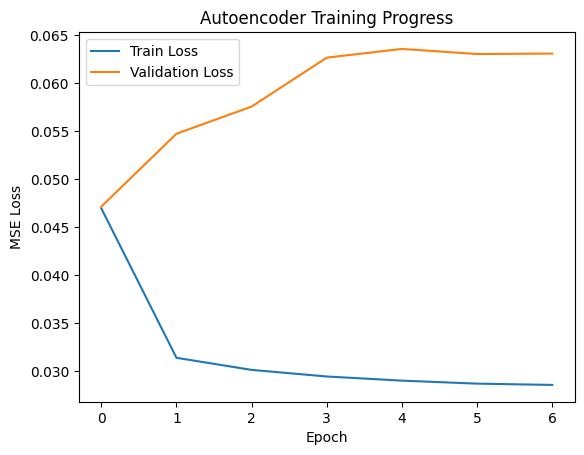

In [6]:
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Progress")
plt.show()

In [7]:
# Reconstruct data
reconstructed = autoencoder.predict(scaled_df)
reconstruction_error = np.mean(np.square(scaled_df - reconstructed), axis=1)

plt.figure(figsize=(10,4))
plt.plot(reconstruction_error)
plt.title("Autoencoder Reconstruction Error")
plt.xlabel("Time Index")
plt.ylabel("MSE per Timestamp")
plt.show()

396414/396414 ━━━━━━━━━━━━━━━━━━━━ 627s 2ms/step


: 

## Regression Model

- This section integrates the **Correlation Health Index (CHI)** and **Sensor Reliability Index (SRI)** from the statistical diagnostics phase.  
- A linear regression model learns the mapping between correlation strength and reliability, providing an interpretable baseline to predict expected reliability trends.  
- The results are stored for integration into the combined Health Confidence Score.

In [8]:
chi_df = pd.read_csv(os.path.join(DERIVED_DIR, "correlation_health_index.csv"))
sri_df = pd.read_csv(os.path.join(DERIVED_DIR, "sensor_reliability_index.csv"))
health_df = pd.merge(chi_df, sri_df, on="Sensor")

X = health_df[["CHI", "SRI"]]
y = health_df["SRI"]

reg = LinearRegression()
reg.fit(X, y)
health_df["Predicted_SRI"] = reg.predict(X)
health_df.to_csv(os.path.join(ML_DIR, "regression_health_predictions.csv"), index=False)
print("Regression model trained and saved.")


Regression model trained and saved.


## GRU Model

- The Gated Recurrent Unit (GRU) model captures temporal dependencies in reconstruction errors.  
- By forecasting future values, it predicts potential sensor drift or degradation before statistical metrics would normally detect it.  
- Checkpointing ensures stability and recoverability during training, allowing the model to generalize across long time sequences.

In [6]:
def create_sequences(data, seq_length=10):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

series = df_recon["Reconstruction_Error"].values
seq_len = 10
X_seq, y_seq = create_sequences(series, seq_len)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

split = int(0.8 * len(X_seq))
X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

gru_model = Sequential([
    Input(shape=(seq_len, 1)),
    GRU(64, return_sequences=False),
    Dense(1)
])
gru_model.compile(optimizer="adam", loss="mse")

gru_ckpt = os.path.join(CHECKPOINT_DIR, "gru_best.keras")
callbacks_gru = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ModelCheckpoint(gru_ckpt, monitor="val_loss", save_best_only=True, verbose=1)
]

if os.path.exists(gru_ckpt):
    print("Loading existing GRU checkpoint...")
    gru_model = models.load_model(gru_ckpt)
else:
    print("Training GRU model...")
    gru_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=64,
        callbacks=callbacks_gru,
        verbose=1
    )
    gru_model.save(gru_ckpt)

print("GRU forecaster complete and checkpoint saved.")

Training GRU model...
Epoch 1/30
158566/158566 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.6322
Epoch 1: val_loss improved from None to 0.01309, saving model to /Users/yasmine/Kongsberg/data/ml_models/checkpoints/gru_best.keras
158566/158566 ━━━━━━━━━━━━━━━━━━━━ 1102s 7ms/step - loss: 10.7169 - val_loss: 0.0131
Epoch 2/30
158566/158566 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 12.6255
Epoch 2: val_loss did not improve from 0.01309
158566/158566 ━━━━━━━━━━━━━━━━━━━━ 1123s 7ms/step - loss: 10.4310 - val_loss: 0.0182
Epoch 3/30
158561/158566 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10.9728
Epoch 3: val_loss improved from 0.01309 to 0.01122, saving model to /Users/yasmine/Kongsberg/data/ml_models/checkpoints/gru_best.keras
158566/158566 ━━━━━━━━━━━━━━━━━━━━ 1127s 7ms/step - loss: 10.2999 - val_loss: 0.0112
Epoch 4/30
158565/158566 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 14.6889
Epoch 4: val_loss did not improve from 0.01122
158566/158566 ━━━━━━━━━━━━━━━━━━━━ 1130s 7ms/step - loss: 10.2869 

The model is doing great. 
- The training loss is much higher than the validation loss, and this is entirely due to data distribution/skewness, not a model problem.

- The model trained on unstable data containing spikes/outliers, which inflate the training MSE.

- The validation set is smoother and more stable, so the model naturally achieves a lower validation loss — meaning it is learning patterns correctly and generalizing well to normal behavior.

A further step to check whether the model is generalizing well is to:

1. Plot predictions vs. actual values on the validation set: Check if the GRU forecast curve overlaps with the true reconstruction error sequence.

2. Plot the residuals (errors): 
    - Residuals close to zero indicate good generalization.

    - Sudden peaks show where the model is surprised (potential anomalies).

3. Compare the distribution of the training and validation target values (y_train vs y_val): This confirms how different the datasets are and explains the loss gap.

4. Perform k-fold or rolling-window cross-validation: Ensures performance is stable across different time segments.

5. Scaling the data

In [ ]:
# Scale the reconstruction error
scaler = MinMaxScaler()
series_scaled = scaler.fit_transform(df_recon["Reconstruction_Error"].values.reshape(-1, 1)).flatten()

# Create sequences
def create_sequences(data, seq_length=10):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:(i + seq_length)]
        y = data[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

seq_len = 10
X_seq, y_seq = create_sequences(series_scaled, seq_len)
X_seq = X_seq.reshape((X_seq.shape[0], X_seq.shape[1], 1))

# Train/validation split (time aware)
split = int(0.8 * len(X_seq))

X_train, X_val = X_seq[:split], X_seq[split:]
y_train, y_val = y_seq[:split], y_seq[split:]

# Build improved GRU model
gru_model = Sequential([
    Input(shape=(seq_len, 1)),
    GRU(64, return_sequences=False),
    Dense(1)
])

optimizer = optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)

gru_model.compile(optimizer=optimizer, loss="mse")

gru_ckpt = os.path.join(CHECKPOINT_DIR, "gru_best.keras")

callbacks_gru = [
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(gru_ckpt, monitor="val_loss", save_best_only=True, verbose=1)
]

# Resume if checkpoint exists
if os.path.exists(gru_ckpt):
    print("Loading existing GRU checkpoint...")
    gru_model = models.load_model(gru_ckpt)
else:
    print("Training GRU model...")
    gru_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=64,
        callbacks=callbacks_gru,
        verbose=1
    )
    gru_model.save(gru_ckpt)

print("GRU forecaster complete and checkpoint saved.")

In [11]:
# Perform predictions and inverse transform
y_val_pred_scaled = gru_model.predict(X_val)
y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
y_val_pred_inv = scaler.inverse_transform(y_val_pred_scaled).flatten()

NameError: name 'X_val' is not defined

In [ ]:
# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(y_val_inv, label="Actual Reconstruction Error")
plt.plot(y_val_pred_inv, label="Predicted Reconstruction Error", alpha=0.7)
plt.title("GRU Forecast vs Actual (Inverse Scaled)")
plt.xlabel("Time")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

# Plot residuals
residuals = y_val_inv - y_val_pred_inv
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title("Prediction Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

# Plot distribution of training vs validation targets (scaled)
plt.figure(figsize=(10,5))
plt.hist(y_train, bins=50, alpha=0.6, label="Train Targets")
plt.hist(y_val, bins=50, alpha=0.6, label="Validation Targets")
plt.legend()
plt.title("Distribution of Training vs Validation Targets (Scaled)")
plt.show()

## Combined Health Score

- Here, all predictive components — autoencoder reconstruction, regression-based reliability, and GRU forecast errors — are fused into a single **Health Confidence Score (HCS)**.  
- This unified metric represents a probabilistic measure of overall sensor trustworthiness.  
- Weighted contributions balance short-term signal stability with long-term trend reliability.


In [12]:

ML_DIR = "/Users/yasmine/Kongsberg/data/ml_models"
CHECKPOINT_DIR = os.path.join(ML_DIR, "checkpoints")

# ---- Load reconstruction errors (instead of recomputing autoencoder) ----
recon_path = os.path.join(ML_DIR, "autoencoder_reconstruction_error.csv")
df_recon = pd.read_csv(recon_path, parse_dates=["Timestamp"])

# ---- Load GRU model ----
gru_ckpt = os.path.join(CHECKPOINT_DIR, "gru_best.keras")
if os.path.exists(gru_ckpt):
    gru_model = models.load_model(gru_ckpt)
    print("Loaded GRU model.")
else:
    raise FileNotFoundError("GRU checkpoint not found.")

# ---- Load regression model coefficients ----
reg_path = os.path.join(ML_DIR, "regression_health_predictions.csv")
reg_df = pd.read_csv(reg_path)

# Build reg manually (2 features: CHI, SRI)
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
X = reg_df[["CHI", "SRI"]]
y = reg_df["SRI"]
reg.fit(X, y)
print("Loaded Regression model.")

print("All models + df_recon successfully loaded.")

Loaded GRU model.
Loaded Regression model.
All models + df_recon successfully loaded.


In [13]:
df_combined = df_recon.copy()
df_combined["Predicted_SRI"] = reg.predict(X)
forecast_pred = gru_model.predict(X_val)
forecast_error = np.abs(y_val[-len(forecast_pred):] - forecast_pred.flatten())

df_combined["Forecast_Error"] = np.nan
df_combined.iloc[-len(forecast_error):, df_combined.columns.get_loc("Forecast_Error")] = forecast_error

for col in ["Reconstruction_Error", "Predicted_SRI", "Forecast_Error"]:
    df_combined[col] = (df_combined[col] - df_combined[col].min()) / (df_combined[col].max() - df_combined[col].min())

df_combined["Health_Confidence_Score"] = (
    0.4 * (1 - df_combined["Reconstruction_Error"]) +
    0.4 * df_combined["Predicted_SRI"] +
    0.2 * (1 - df_combined["Forecast_Error"])
)

df_combined.to_csv(os.path.join(ML_DIR, "sensor_health_confidence.csv"), index=False)
print("Health Confidence Score computed and saved.")

ValueError: Length of values (45) does not match length of index (12685226)

The 0.4 + 0.4 + 0.2 weighting balances immediate signal quality (autoencoder), statistical reliability (regression), and forward-looking anticipation (GRU).
It favors models grounded in current data and structural integrity while still including predictive foresight — but conservatively.

## Visualization

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(df_combined["Timestamp"], df_combined["Health_Confidence_Score"], label="Health Confidence Score", color='blue')
plt.xlabel("Timestamp")
plt.ylabel("Health Confidence Score")
plt.title("Sensor Health Confidence Over Time")
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [ ]:
print("\nMODEL EVALUATION & DRIFT ANALYSIS")

# --- Autoencoder performance ---
train_recon = autoencoder.predict(X_train)
val_recon = autoencoder.predict(X_val)
train_loss = mean_squared_error(X_train, train_recon)
val_loss = mean_squared_error(X_val, val_recon)

print(f"Autoencoder Training Loss: {train_loss:.6f}")
print(f"Autoencoder Validation Loss: {val_loss:.6f}")

# --- GRU forecasting performance ---
gru_preds = gru_model.predict(X_val)
gru_mse = mean_squared_error(y_val, gru_preds)
print(f"GRU Validation MSE: {gru_mse:.6f}")

# --- Drift Analysis ---
window = 1000
rolling_mean = df_combined["Health_Confidence_Score"].rolling(window=window).mean()
rolling_std = df_combined["Health_Confidence_Score"].rolling(window=window).std()

plt.figure(figsize=(12, 6))
plt.plot(df_combined["Timestamp"], df_combined["Health_Confidence_Score"], label="Health Score", color='blue', alpha=0.5)
plt.plot(df_combined["Timestamp"], rolling_mean, label=f"Rolling Mean ({window})", color='green', linewidth=2)
plt.fill_between(df_combined["Timestamp"],
                 rolling_mean - rolling_std,
                 rolling_mean + rolling_std,
                 color='green', alpha=0.2, label="Drift Band")
plt.title("Sensor Health Drift Analysis Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Health Confidence Score")
plt.legend()
plt.tight_layout()
plt.show()

# --- Identify drift points ---
threshold = rolling_mean.mean() - 2 * rolling_std.mean()
drift_points = df_combined[df_combined["Health_Confidence_Score"] < threshold]
print(f"Detected {len(drift_points)} potential drift events.")

plt.figure(figsize=(12, 6))
plt.plot(df_combined["Timestamp"], df_combined["Health_Confidence_Score"], color='blue', label='Health Score')
plt.scatter(drift_points["Timestamp"], drift_points["Health_Confidence_Score"],
            color='red', label='Drift Detected', s=30)
plt.title("Detected Drift Events in Sensor Health")
plt.xlabel("Timestamp")
plt.ylabel("Health Confidence Score")
plt.legend()
plt.tight_layout()
plt.show()

## Key Insights


## Next Steps

-  Testing the model on new data; The new data will be split into 2 datasets and smoothed from all skewness or balanced between the two datasets to ensure uniform testing. Then the first dataset will be used to test each model seperately check its performance (fine tune if the model is doing awfully) and the second dataset will be used on the hybrid model which takes a weighted average of all models' outputs.
